# Modules

In [29]:
from PIL import Image
import numpy as np
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

# Outils

In [17]:
def image_to_grayscale_array(image_path):
    # Charger l'image
    image = Image.open(image_path).convert('L')  # Convertir en niveaux de gris

    # Obtenir les dimensions de l'image
    largeur, hauteur = image.size

    # Créer un tableau pour stocker les valeurs de gris
    grayscale_array = []

    # Parcourir chaque pixel et obtenir sa valeur de gris
    for y in range(hauteur):
        row = []
        for x in range(largeur):
            pixel_value = image.getpixel((x, y))
            grayscale_array.append(pixel_value)

    return grayscale_array

# Data

## Training data

In [23]:
ass=['ass_'+str(i)+'.jpg' for i in range(1,10)]
mag=['mag_'+str(i)+'.jpg' for i in range(1,10)]

X = []
for el in ass+mag:
    X.append(image_to_grayscale_array('C:\\Users\\User\\Documents\\ML_test\\computer vision\\citadelles\\training set_100_64\\'+el))
X=np.array(X)
y=[1]*9+[0]*9 # voleur = 1 / magicien = 0
y=np.array(y)

In [22]:
X.shape

(18, 6400)

## Validation data

In [39]:
ass_val=['ass_'+str(i)+'.jpg' for i in range(1,7)]
mag_val=['mag_'+str(i)+'.jpg' for i in range(1,7)]

X_val = []
for el in ass_val+mag_val:
    X_val.append(image_to_grayscale_array('C:\\Users\\User\\Documents\\ML_test\\computer vision\\citadelles\\training set_100_64\\'+el))
X_val=np.array(X_val)
y_val=[1]*6+[0]*6 # voleur = 1 / magicien = 0
y_val=np.array(y_val)

In [40]:
X_val.shape

(12, 6400)

# Minimization

In [25]:
U, S, V = jnp.linalg.svd(X.T, full_matrices=False)

eigenvalues: [40030.83    5710.6665  4293.8325  4044.6628  3478.3206  3241.8596
  3022.728   2766.9207  2615.2292  2503.8337  2404.98    2293.5625
  2260.391   2177.7244  2067.5276  2008.2684  1901.3604  1803.0325]


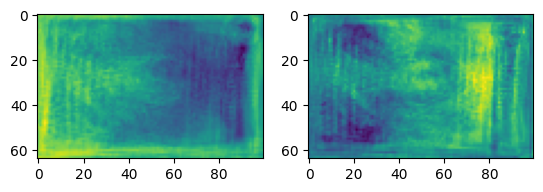

In [32]:
print('eigenvalues: {}'.format(S))
plt.subplot(1,2,1)
plt.imshow(U[:,0].reshape((64,100)))
plt.subplot(1,2,2)
plt.imshow(U[:,1].reshape((64,100)))

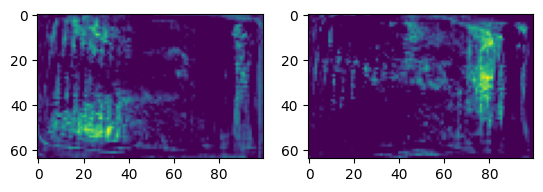

In [35]:
Vty = jnp.matmul(V, y)
SinvVty = jnp.matmul(jnp.diag(1./S), Vty)
a_hat = jnp.matmul(U, SinvVty)

plt.subplot(1,2,1)
plt.imshow(jnp.maximum(a_hat, 0).reshape((64, 100)))
plt.subplot(1,2,2)
plt.imshow(jnp.maximum(-a_hat, 0).reshape((64, 100)))

# Validation

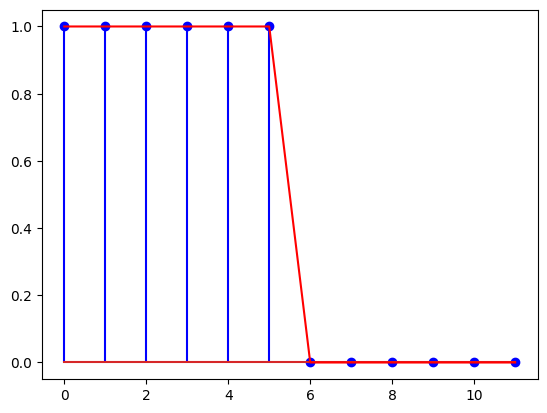

In [42]:
y_hat = jnp.matmul(X_val, a_hat)
plt.stem(range(len(y_val)), y_val, '-b')
plt.plot(range(len(y_val)), y_hat, '-r')